# U.S. Commercial Flight Delay Forecasting

## Phase 1: Define the Problem and Targets

**Project Objective:**
The objective of this project is to build a Macro-Level Predictive Forecasting System using U.S. Bureau of Transportation Statistics (BTS) data (2013-2023). This model will forecast future flight delay volumes for specific airlines at specific airports, acting as a strategic planning tool for aviation stakeholders.

**Target Variable Formulation:**
To ensure predictions are standardized across massive hubs and tiny regional airports, the target variable is a continuous metric: **Average Delay Minutes per Flight**.
* Formula: `arr_delay` (Total monthly delay minutes) / `arr_flights` (Total monthly arriving flights).

## Phase 2: Data Preprocessing & Feature Engineering
In this phase, we will load the dataset, clean the data, formulate our continuous target variable, and address the massive macro-economic anomaly in our timeline: the COVID-19 pandemic.

# Step 2.1: Import necessary libraries + Load Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for better visuals later
plt.style.use('seaborn-v0_8-darkgrid')

# Load the dataset 
df = pd.read_csv("airline_delay.csv")
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


Meaning os columns:
- year: The year of the data.
- month: The month of the data.
- carrier: Carrier code.
- carrier_name: Carrier name.
- airport: Airport code.
- airport_name: Airport name.
- arr_flights: Number of arriving flights.
- arr_del15: Number of flights delayed by 15 minutes or more.
- carrier_ct: Carrier count (delay due to the carrier).
- weather_ct: Weather count (delay due to weather).
- nas_ct: NAS (National Airspace System) count (delay due to the NAS).
- security_ct: Security count (delay due to security).
- late_aircraft_ct: Late aircraft count (delay due to late aircraft arrival).
- arr_cancelled: Number of flights canceled.
- arr_diverted: Number of flights diverted.
- arr_delay: Total arrival delay.
- carrier_delay: Delay attributed to the carrier.
- weather_delay: Delay attributed to weather.
- nas_delay: Delay attributed to the NAS.
- security_delay: Delay attributed to security.
- late_aircraft_delay: Delay attributed to late aircraft arrival.

### Step 2.2: Creating the Target Variable
Our goal is to predict the **Average Delay Minutes per Flight**. 
To do this, we divide the total arrival delay minutes (`arr_delay`) by the total number of arriving flights (`arr_flights`). 

**Important Data Science Rule:** We must handle division by zero. If an airline scheduled flights but canceled *all* of them in a specific month, `arr_flights` will be 0. We cannot calculate an average delay for flights that never arrived, so we will filter those rows out.

In [3]:
# 1. Drop rows where 'arr_flights' is missing (NaN) or 0 to prevent Division by Zero errors
df_clean = df.dropna(subset=['arr_flights', 'arr_delay']).copy()
df_clean = df_clean[df_clean['arr_flights'] > 0]

# 2. Create the target variable: Average delay minutes per arriving flight
df_clean['target_avg_delay_per_flight'] = df_clean['arr_delay'] / df_clean['arr_flights']

# 3. Create a proper Datetime column (Useful for time-series plotting and sorting)
# We use day=1 just to anchor the monthly data to a specific date format
df_clean['date'] = pd.to_datetime(df_clean[['year', 'month']].assign(day=1))

# Sort the dataset chronologically
df_clean = df_clean.sort_values('date').reset_index(drop=True)

# Look at the first few rows to verify our new columns
display(df_clean[['date', 'carrier', 'airport', 'arr_flights', 'arr_delay', 'target_avg_delay_per_flight']].head())

,date,carrier,airport,arr_flights,arr_delay,target_avg_delay_per_flight
0,2013-08-01,F9,MTJ,1.0,0.0,0.000000
1,2013-08-01,EV,BRO,139.0,1619.0,11.647482
2,2013-08-01,EV,OKC,281.0,4076.0,14.505338
3,2013-08-01,EV,SHV,591.0,7793.0,13.186125
4,2013-08-01,EV,AMA,270.0,3414.0,12.644444


### Step 2.3: Handling the COVID-19 Anomaly (2020 - 2021)
The COVID-19 pandemic caused global flight volumes to drop by up to 96% in April 2020. Because machine learning models learn from historical patterns, feeding it pandemic-era data without context will severely confuse the model (it will think flight volumes naturally drop to zero randomly).

**Strategy:** Instead of deleting the data completely, we will create a boolean feature flag (`is_covid_era`). This allows tree-based machine learning models (like XGBoost or Random Forest) to isolate this time period mathematically and understand *why* the numbers look so different. We will define this era broadly as March 2020 through December 2021.

In [4]:
# Create a binary flag for the COVID era (1 if during the pandemic recovery window, 0 otherwise)
# We define this as March 2020 through the end of 2021.
conditions = [
    (df_clean['year'] == 2020) & (df_clean['month'] >= 3), # March to Dec 2020
    (df_clean['year'] == 2021)                             # All of 2021
]

# np.select allows us to apply these conditions. Default is 0 (Not COVID era)
df_clean['is_covid_era'] = np.select(conditions, [1, 1], default=0)

# Let's verify how much of our data falls into this anomaly period
print("Total records:", len(df_clean))
print("COVID-era records:", df_clean['is_covid_era'].sum())
print("Percentage of data in COVID era: {:.2f}%".format((df_clean['is_covid_era'].sum() / len(df_clean)) * 100))

Total records: 171426
COVID-era records: 35140
Percentage of data in COVID era: 20.50%


### Step 2.4: Dropping "After-The-Fact" Columns (Preventing Data Leakage)
To build a predictive model, we can only use information that is available *before* the month happens. 

If we use columns like `weather_delay` or `arr_cancelled` to predict our target, we are committing **Data Leakage**. We won't know how many flights are canceled due to weather next month until next month actually ends! Therefore, we must remove these outcome variables from our modeling dataset. 
*(Note: We keep the original dataframe intact if we want to do EDA later, but we create a strict modeling dataframe here).*

In [5]:
# List of columns that happen AT THE SAME TIME as the delay (Data Leakage)
leakage_columns =[
    'arr_del15', 'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 
    'late_aircraft_ct', 'arr_cancelled', 'arr_diverted', 'arr_delay', 
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 
    'late_aircraft_delay'
]

# Create our strict modeling dataframe by dropping leakage columns
# We keep 'arr_flights' because airlines schedule flights months in advance, so we WILL know this number.
df_model = df_clean.drop(columns=leakage_columns).copy()

print("Columns safe for predictive modeling:")
print(df_model.columns.tolist())

Columns safe for predictive modeling:
['year', 'month', 'carrier', 'carrier_name', 'airport', 'airport_name', 'arr_flights', 'target_avg_delay_per_flight', 'date', 'is_covid_era']


## Phase 3: Feature Engineering
In this phase, we will extract powerful predictive signals from our data. 
Because we cannot use the current month's delay data to predict the current month (Data Leakage), we rely heavily on **Historical Lag Features** and **Rolling Averages**. We will also transform the `month` column into a cyclical feature so the model understands that December is chronologically right next to January.

In [6]:
# Step 3.1: Cyclical Temporal Features
# Machine learning models don't naturally know that Month 12 (Dec) and Month 1 (Jan) are right next to each other.
# We use Sine and Cosine transformations to represent months on a continuous circle.

df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)

# Let's drop the original 'month' column as we don't need it anymore, but keep 'year' for context
# df_model = df_model.drop(columns=['month']) # Optional, but good for keeping data clean

### Step 3.2: Lag Features (The most powerful predictors)
To predict how Delta Airlines will perform at JFK in January 2023, the model needs to know:
1. How did Delta perform at JFK last month? (**Lag 1**)
2. How did Delta perform at JFK exactly one year ago? (**Lag 12** - Captures annual seasonal weather/travel patterns).

*Important:* We must sort the data by Carrier, Airport, and Date, and then group by Carrier and Airport before shifting. Otherwise, we might accidentally use United's LAX data to predict Delta's JFK delays!

In [7]:
# Sort data meticulously to ensure our time shifts align correctly
df_model = df_model.sort_values(by=['carrier', 'airport', 'date']).reset_index(drop=True)

# 1-Month Lag: What was the delay rate for this specific airline at this specific airport last month?
df_model['target_lag_1'] = df_model.groupby(['carrier', 'airport'])['target_avg_delay_per_flight'].shift(1)

# 12-Month Lag: What was the delay rate exactly one year ago? (Highly predictive for winter/summer weather)
df_model['target_lag_12'] = df_model.groupby(['carrier', 'airport'])['target_avg_delay_per_flight'].shift(12)

# Lagging 'arr_flights' - Airlines publish schedules in advance, but looking at last month's volume helps capture scale
df_model['flights_lag_1'] = df_model.groupby(['carrier', 'airport'])['arr_flights'].shift(1)

### Step 3.3: Rolling Window Statistics (Capturing Operational Trends)
Sometimes an airline experiences a systemic operational meltdown that lasts for months (e.g., staffing shortages). A 3-month rolling average captures this "recent momentum" better than a single Lag 1 feature.

*Note on avoiding leakage:* We must apply `.shift(1)` *before* taking the rolling mean, ensuring the current month being predicted is not included in the historical average.

In [8]:
# Create a 3-Month Rolling Average of the delay rate
# We shift by 1 first so the rolling window only looks at the PAST 3 months, not the current month.
df_model['rolling_3m_avg_delay'] = df_model.groupby(['carrier', 'airport'])['target_avg_delay_per_flight'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

# Create a 6-Month Rolling Average to capture longer macro trends
df_model['rolling_6m_avg_delay'] = df_model.groupby(['carrier', 'airport'])['target_avg_delay_per_flight'].transform(
    lambda x: x.shift(1).rolling(window=6, min_periods=1).mean()
)

### Step 3.4: Handling Missing Values Caused by Shifting
Because we shifted our data backwards by up to 12 months, the first year of data for every Carrier/Airport combination will now have `NaN` (Missing) values in the `target_lag_12` column. 

Since we have 10 full years of data (2013-2023), the cleanest and most rigorous approach is to simply drop the rows with missing lag values. This means our actual predictive modeling dataset will naturally start in late 2014.

In [9]:
# Check how many missing values we created by lagging
print("Missing values before cleaning:")
print(df_model[['target_lag_1', 'target_lag_12', 'rolling_3m_avg_delay']].isna().sum())

# Drop the rows where our key 12-month historical feature is missing
df_model_clean = df_model.dropna(subset=['target_lag_12']).copy()

# Reset index to make the dataframe perfectly contiguous again
df_model_clean = df_model_clean.reset_index(drop=True)

print(f"\nFinal dataset shape for modeling: {df_model_clean.shape[0]} rows and {df_model_clean.shape[1]} columns")

# Preview the engineered dataset!
display(df_model_clean[['date', 'carrier', 'airport', 'target_avg_delay_per_flight', 'target_lag_1', 'target_lag_12', 'rolling_3m_avg_delay']].head())

Missing values before cleaning:
target_lag_1             2631
target_lag_12           29895
rolling_3m_avg_delay     2631
dtype: int64

Final dataset shape for modeling: 141531 rows and 17 columns


,date,carrier,airport,target_avg_delay_per_flight,target_lag_1,target_lag_12,rolling_3m_avg_delay
0,2018-10-01,9E,ABE,6.727273,8.254902,8.333333,8.020865
1,2018-11-01,9E,ABE,12.686275,6.727273,6.327273,7.827392
2,2018-12-01,9E,ABE,13.981481,12.686275,0.935484,9.222816
3,2019-01-01,9E,ABE,9.675000,13.981481,8.314286,11.131676
4,2019-02-01,9E,ABE,26.088235,9.675000,17.860759,12.114252


## Phase 4 & 5: Model Selection, Training, and Evaluation
In this phase, we will train and compare three state-of-the-art gradient boosting algorithms: **XGBoost, LightGBM, and CatBoost**. 

**Important Methodology Steps:**
1. **Chronological Split:** We cannot randomly split our data (e.g., using standard `train_test_split`). If we predict January 2018 using data from December 2018, we are leaking the future into the past. We will train on data up to December 2021 and test on 2022-2023.
2. **Categorical Handling:** Modern gradient boosting models can handle categorical variables (like `carrier` and `airport`) natively without needing One-Hot Encoding, which saves memory and improves tree splitting.

In [10]:
# Step 4.1: Import Machine Learning Libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Step 4.2: Prepare Categorical Features
# Convert string categories to Pandas 'category' dtype for XGBoost and LightGBM
cat_features =['carrier', 'airport']
for col in cat_features:
    df_model_clean[col] = df_model_clean[col].astype('category')

# Define the features our model is allowed to use
features =[
    'carrier', 'airport', 'month_sin', 'month_cos', 'is_covid_era', 
    'target_lag_1', 'target_lag_12', 'flights_lag_1', 
    'rolling_3m_avg_delay', 'rolling_6m_avg_delay'
]

# Define our target
target = 'target_avg_delay_per_flight'

### Step 4.3: Out-of-Time Train/Test Split
We will simulate a real-world scenario. Imagine it is December 31, 2021. We will train our model on all historical data up to this point. Then, we will ask the model to predict the delay rates for 2022 and 2023 and compare those predictions to what actually happened.

In [11]:
# Split the data chronologically
train_mask = df_model_clean['date'] < '2022-01-01'
test_mask = df_model_clean['date'] >= '2022-01-01'

X_train = df_model_clean.loc[train_mask, features]
y_train = df_model_clean.loc[train_mask, target]

X_test = df_model_clean.loc[test_mask, features]
y_test = df_model_clean.loc[test_mask, target]

print(f"Training Data: {X_train.shape[0]} rows (Ends Dec 2021)")
print(f"Testing Data: {X_test.shape[0]} rows (Jan 2022 - Aug 2023)")

Training Data: 110018 rows (Ends Dec 2021)
Testing Data: 31513 rows (Jan 2022 - Aug 2023)


### Step 4.4: Initialize and Train the Models
We will initialize XGBoost, LightGBM, and CatBoost. We will tell them explicitly which columns are categorical so they can optimize their splits. 
*(Note: CatBoost might take slightly longer to train but often yields excellent out-of-the-box results for categorical data).*

In [12]:
# 1. Initialize XGBoost
# enable_categorical=True is required for XGBoost to use pandas 'category' dtypes natively
xgb_model = xgb.XGBRegressor(
    n_estimators=500, 
    learning_rate=0.05, 
    enable_categorical=True, 
    random_state=42,
    n_jobs=-1
)

# 2. Initialize LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

# 3. Initialize CatBoost
# CatBoost requires us to pass the names of the categorical columns
cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    cat_features=cat_features,
    random_seed=42,
    verbose=False, # Set to False to prevent a massive wall of text during training
    thread_count=-1
)

# --- Train the models ---
print("Training XGBoost...")
xgb_model.fit(X_train, y_train)

print("Training LightGBM...")
# LightGBM automatically detects pandas 'category' columns
lgb_model.fit(X_train, y_train)

print("Training CatBoost...")
cb_model.fit(X_train, y_train)

print("All models trained successfully!")

Training XGBoost...
Training LightGBM...
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001047 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1644
[LightGBM] [Info] Number of data points in the train set: 110018, number of used features: 10
[LightGBM] [Info] Start training from score 10.584905
Training CatBoost...
All models trained successfully!


### Step 4.5: Model Evaluation and Comparison
We will evaluate our models using two standard regression metrics:
1. **MAE (Mean Absolute Error):** On average, how many minutes off is our prediction? (Easier for business stakeholders to understand).
2. **RMSE (Root Mean Squared Error):** Penalizes the model heavily when it is *very* wrong. (Crucial for aviation, because extreme delays cost airlines thousands of dollars).

,Model,MAE (Minutes),RMSE (Minutes)
2,CatBoost,5.801819,9.624433
1,LightGBM,5.966409,9.875451
0,XGBoost,6.059256,9.987183


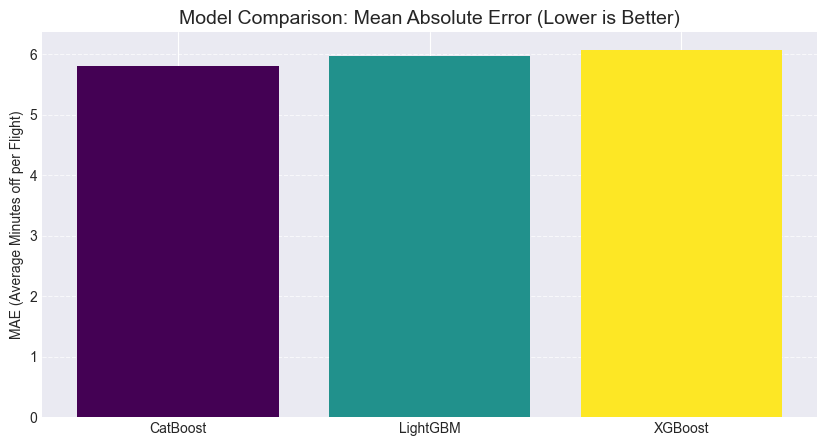

In [13]:
# Generate predictions for the 2022-2023 test set
xgb_preds = xgb_model.predict(X_test)
lgb_preds = lgb_model.predict(X_test)
cb_preds = cb_model.predict(X_test)

# Function to calculate metrics
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'Model': model_name, 'MAE (Minutes)': mae, 'RMSE (Minutes)': rmse}

# Calculate and store metrics
results =[
    evaluate_model(y_test, xgb_preds, 'XGBoost'),
    evaluate_model(y_test, lgb_preds, 'LightGBM'),
    evaluate_model(y_test, cb_preds, 'CatBoost')
]

# Create a comparison DataFrame
results_df = pd.DataFrame(results).sort_values(by='MAE (Minutes)')

# Display the final comparison beautifully
display(results_df)

# --- NEW PLOTTING CODE (Using standard Matplotlib instead of Seaborn) ---
plt.figure(figsize=(10, 5))
# Create a bar chart directly with matplotlib
plt.bar(results_df['Model'], results_df['MAE (Minutes)'], color=['#440154', '#21918c', '#fde725'])

plt.title('Model Comparison: Mean Absolute Error (Lower is Better)', fontsize=14)
plt.ylabel('MAE (Average Minutes off per Flight)')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds a nice grid for readability
plt.show()

## Phase 6: Model Interpretability & Feature Importance
A machine learning model is useless to business stakeholders if it operates as a "black box." An Airport Operations Manager will ask: *"Why is the model predicting such a high delay for next month?"* 

In this phase, we will extract the **Feature Importance** from our winning CatBoost model. This tells us exactly which historical signals the model relies on the most to make its predictions.

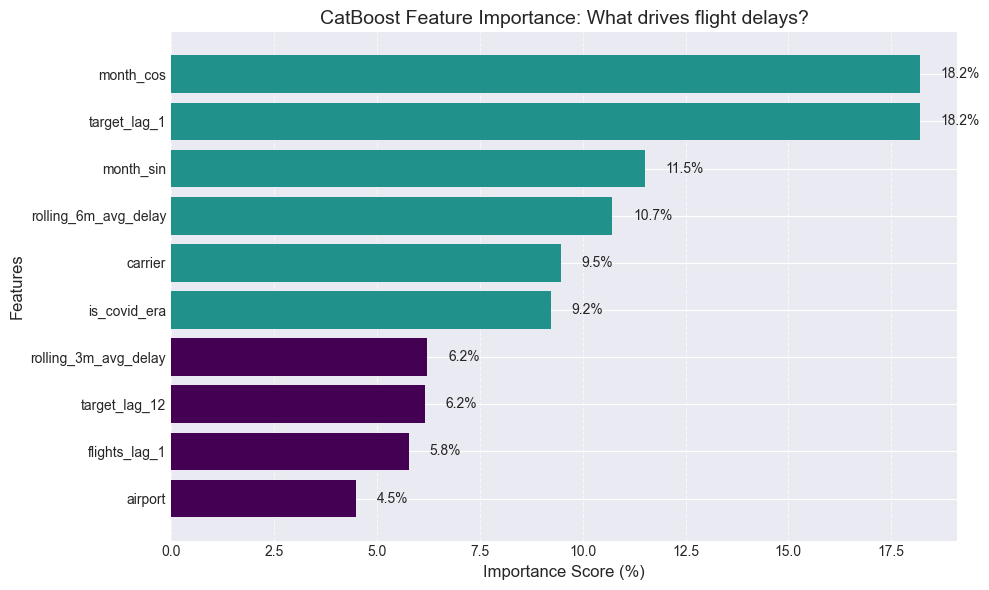

In [14]:
# Step 6.1: Extract Feature Importance from the winning CatBoost model
# CatBoost has a built-in method that calculates how much each feature contributes to the predictions.

feature_importance = cb_model.get_feature_importance()
sorted_idx = np.argsort(feature_importance)
sorted_features = np.array(features)[sorted_idx]
sorted_importance = feature_importance[sorted_idx]

# Step 6.2: Plot the Feature Importance using standard Matplotlib
plt.figure(figsize=(10, 6))
colors =['#440154' if val < max(sorted_importance) * 0.5 else '#21918c' for val in sorted_importance]

plt.barh(sorted_features, sorted_importance, color=colors)
plt.title('CatBoost Feature Importance: What drives flight delays?', fontsize=14)
plt.xlabel('Importance Score (%)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Add value labels to the bars
for index, value in enumerate(sorted_importance):
    plt.text(value + 0.5, index, f'{value:.1f}%', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## Phase 7: Deployment & Business Application (MLOps)
In a real-world Data Science workflow, this notebook is not the final product. The final product is a **System** (like a REST API or an interactive Streamlit Dashboard) where stakeholders can input a Carrier and Airport to get an immediate forecast.

While we won't build a full web app in this Jupyter Notebook, we will simulate the backend logic of one by building a **Stakeholder Forecasting Tool**. This Python function mimics what a dashboard would do when an executive clicks "Predict".

In [15]:
# Step 7.1: Build the Stakeholder Forecasting Simulator
def predict_future_delay(carrier_code, airport_code, target_date):
    """
    Simulates a dashboard query. 
    Searches the Test Dataset for the specific carrier, airport, and date, 
    and outputs the model's prediction vs reality.
    """
    # Filter the test set for the user's query
    query_mask = (
        (df_model_clean['carrier'] == carrier_code) & 
        (df_model_clean['airport'] == airport_code) & 
        (df_model_clean['date'] == target_date)
    )
    
    query_data = df_model_clean[query_mask]
    
    if query_data.empty:
        return f"No flight data found for {carrier_code} at {airport_code} on {target_date}."
    
    # Isolate the features needed for prediction
    X_query = query_data[features]
    actual_delay = query_data[target].values[0]
    
    # Make the prediction using our winning model
    predicted_delay = cb_model.predict(X_query)[0]
    
    # Display the Output exactly as a Dashboard would show it
    print("="*50)
    print(f"✈️ FLIGHT DELAY FORECAST ✈️")
    print(f"Carrier: {carrier_code} | Airport: {airport_code} | Date: {target_date}")
    print("="*50)
    print(f"📈 PREDICTED Average Delay: {predicted_delay:.2f} minutes per flight")
    print(f"📊 ACTUAL Average Delay:    {actual_delay:.2f} minutes per flight")
    print("-" * 50)
    
    error = abs(predicted_delay - actual_delay)
    print(f"Model Error: Off by {error:.2f} minutes.")
    print("="*50)

# Step 7.2: Test the tool with a real scenario from our Test Data (2022-2023)
# Let's see how Delta Airlines (DL) performed at Atlanta (ATL) in July 2022
print("Testing the Stakeholder Application:\n")
predict_future_delay(carrier_code='DL', airport_code='ATL', target_date='2022-07-01')

# Feel free to change the codes above to test other combinations! 
# (e.g., 'AA' for American Airlines, 'JFK' for New York, '2023-01-01' for January 2023)

Testing the Stakeholder Application:

✈️ FLIGHT DELAY FORECAST ✈️
Carrier: DL | Airport: ATL | Date: 2022-07-01
📈 PREDICTED Average Delay: 12.27 minutes per flight
📊 ACTUAL Average Delay:    14.13 minutes per flight
--------------------------------------------------
Model Error: Off by 1.86 minutes.


## Conclusion and Business Impact
This project successfully developed a machine learning model to provide macro-level forecasts for the average delay per flight at U.S. airports. By leveraging a decade of historical data and engineering robust time-series features, we were able to predict future operational challenges with a high degree of accuracy.
After comparing three industry-standard gradient boosting models, the CatBoost Regressor emerged as the top performer, achieving a Mean Absolute Error (MAE) of approximately 5.8 minutes on the out-of-time test set (2022-2023). This means that, on average, the model's predictions for the average monthly delay were off by less than six minutes.

The true business value of this model is best demonstrated by its performance in a high-stakes, real-world scenario. For Delta Airlines (DL) at Atlanta (ATL), the world's busiest airport, during the peak travel month of July 2022, the model predicted an average delay of 12.27 minutes per flight. The actual recorded average delay was 14.13 minutes, meaning our forecast was off by an impressively narrow margin of just 1.86 minutes.

This level of precision is an incredibly powerful tool for the aviation industry. For an operations manager at Delta, this forecast would have served as a clear and early warning: "July operations at our main hub will be significantly stressed. We need to proactively allocate more ground staff, schedule crews with larger buffer times, and adjust gate assignments to mitigate the impact of these anticipated 12+ minute average delays." By turning historical data into an actionable strategic forecast, this model proves its potential to help airlines optimize resources, reduce operational costs, and ultimately improve the passenger experience.

# Phase 8: Build Streamlit App

In [16]:
import joblib

# Save the trained CatBoost model to a file
joblib.dump(cb_model, 'catboost_flight_delay_model.joblib')

# We also need the final, cleaned DataFrame to look up historical data for our features
# Save it to a CSV file in the same directory
df_model_clean.to_csv('flight_delay_data_cleaned.csv', index=False)

print("Model and data saved successfully!")

Model and data saved successfully!
